Shape before balancing: (8128, 2)
Using text column: overview_enhanced

Counts by label before balancing:
label
Action     2032
Comedy     2032
Horror     2032
Romance    2032
Name: count, dtype: int64

Classes:
0 -> Action
1 -> Comedy
2 -> Horror
3 -> Romance

Loading saved split/tokenizer...


Loaded saved tokenizer and test split.

Train size: 6502
Val size: 813
Test size: 813

Loading existing model and history...
Loaded model and history.

Test Loss: 0.11572986096143723
Test Accuracy: 0.9471094608306885

Classification Report:
              precision    recall  f1-score   support

      Action       0.95      0.93      0.94       204
      Comedy       0.90      0.96      0.93       203
      Horror       0.97      0.95      0.96       203
     Romance       0.97      0.95      0.96       203

    accuracy                           0.95       813
   macro avg       0.95      0.95      0.95       813
weighted avg       0.95      0.95      0.95       813

Saved: gru_test_predictions.csv
Saved: gru_test_misclassified.csv


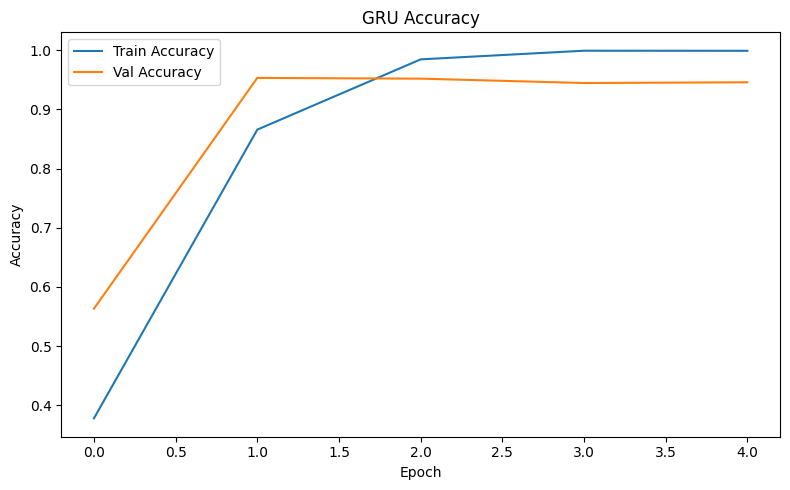

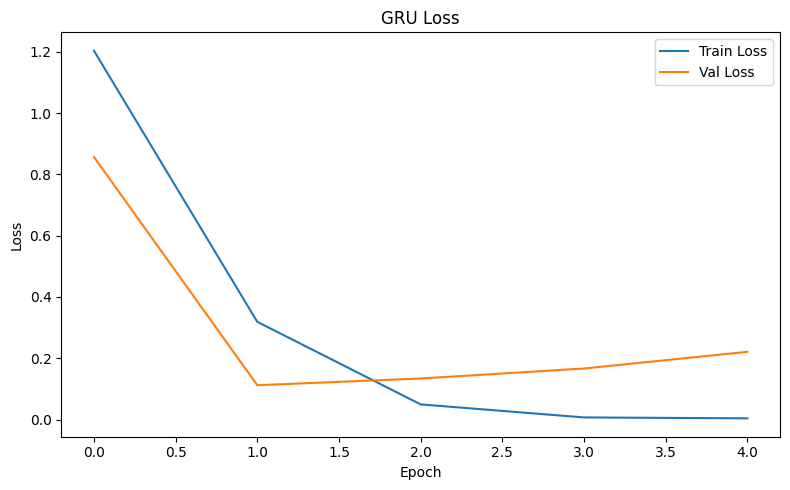

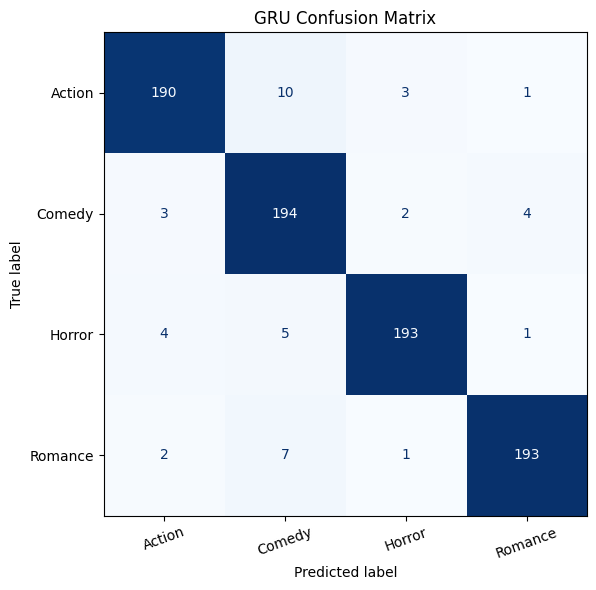

Saved: gru_confusion_matrix.png

All done successfully.


In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer, tokenizer_from_json
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# =========================================
# 1) PATHS
# =========================================
DATA_PATH = r"C:\Users\user\OneDrive - Helwan National University\Desktop\NN\tmdb_text_image_only.csv"

MODEL_PATH = "gru_movie_genre_model.h5"
HISTORY_PATH = "gru_history.json"
TOKENIZER_PATH = "gru_tokenizer.json"
LABEL_MAP_PATH = "gru_label_map.json"

X_TEST_TEXT_PATH = "gru_X_test_texts.csv"
Y_TEST_PATH = "gru_y_test.npy"
X_TEST_PAD_PATH = "gru_X_test_pad.npy"

TEST_RESULTS_PATH = "gru_test_predictions.csv"
MISCLASSIFIED_PATH = "gru_test_misclassified.csv"
CM_IMAGE_PATH = "gru_confusion_matrix.png"

# =========================================
# 2) SETTINGS
# =========================================
TEXT_COL = "overview_enhanced"
LABEL_COL = "label"

MAX_WORDS = 20000
MAX_LEN = 120
OOV_TOKEN = "<OOV>"

DO_BALANCE = True

# لو عايزة كل class يبقى نفس رقم ثابت
USE_FIXED_BALANCE = False
FIXED_BALANCE_COUNT = 2032

# =========================================
# 3) CHECK DATASET
# =========================================
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found:\n{DATA_PATH}\n\n"
        "عدلي DATA_PATH للمكان الصحيح للملف."
    )

# =========================================
# 4) LOAD DATA
# =========================================
df = pd.read_csv(DATA_PATH)

if TEXT_COL not in df.columns:
    TEXT_COL = "overview_clean"

if LABEL_COL not in df.columns:
    raise ValueError(f"Column '{LABEL_COL}' not found. Available columns: {df.columns.tolist()}")

df = df[[TEXT_COL, LABEL_COL]].dropna().copy().reset_index(drop=True)
df[TEXT_COL] = df[TEXT_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)

print("Shape before balancing:", df.shape)
print("Using text column:", TEXT_COL)
print("\nCounts by label before balancing:")
print(df[LABEL_COL].value_counts())



# =========================================
# 6) LABEL ENCODING
# =========================================
le = LabelEncoder()
df["label_encoded"] = le.fit_transform(df[LABEL_COL])

X = df[TEXT_COL].to_numpy()
y = df["label_encoded"].to_numpy()

label_map = {int(i): c for i, c in enumerate(le.classes_)}

with open(LABEL_MAP_PATH, "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

print("\nClasses:")
for i, c in label_map.items():
    print(i, "->", c)

# =========================================
# 7) LOAD OR CREATE TEST SPLIT
# =========================================
need_split = not (
    os.path.exists(X_TEST_TEXT_PATH)
    and os.path.exists(Y_TEST_PATH)
    and os.path.exists(X_TEST_PAD_PATH)
    and os.path.exists(TOKENIZER_PATH)
)

if need_split:
    print("\nSaved split/tokenizer not found -> creating split...")

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=0.5,
        random_state=42,
        stratify=y_temp
    )

    tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token=OOV_TOKEN)
    tokenizer.fit_on_texts(X_train)

    X_train_seq = tokenizer.texts_to_sequences(X_train)
    X_val_seq   = tokenizer.texts_to_sequences(X_val)
    X_test_seq  = tokenizer.texts_to_sequences(X_test)

    X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
    X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")
    X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding="post", truncating="post")

    with open(TOKENIZER_PATH, "w", encoding="utf-8") as f:
        f.write(tokenizer.to_json())

    pd.DataFrame({"text": X_test}).to_csv(X_TEST_TEXT_PATH, index=False, encoding="utf-8-sig")
    np.save(Y_TEST_PATH, y_test)
    np.save(X_TEST_PAD_PATH, X_test_pad)

    print("Saved tokenizer and test split.")

else:
    print("\nLoading saved split/tokenizer...")

    X_test_df = pd.read_csv(X_TEST_TEXT_PATH)
    X_test = X_test_df["text"].astype(str).to_numpy()
    y_test = np.load(Y_TEST_PATH)
    X_test_pad = np.load(X_TEST_PAD_PATH)

    with open(TOKENIZER_PATH, "r", encoding="utf-8") as f:
        tokenizer_json = f.read()
    tokenizer = tokenizer_from_json(tokenizer_json)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    X_val, _, y_val, _ = train_test_split(
        X_temp, y_temp,
        test_size=0.5,
        random_state=42,
        stratify=y_temp
    )

    X_train_seq = tokenizer.texts_to_sequences(X_train)
    X_val_seq   = tokenizer.texts_to_sequences(X_val)

    X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
    X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding="post", truncating="post")

    print("Loaded saved tokenizer and test split.")

print("\nTrain size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))

# =========================================
# 8) LOAD OR TRAIN MODEL
# =========================================
need_train = not (os.path.exists(MODEL_PATH) and os.path.exists(HISTORY_PATH))

if need_train:
    print("\nModel or history missing -> training model...")

    num_classes = len(label_map)

    model = Sequential([
        Embedding(input_dim=MAX_WORDS, output_dim=128),
        SpatialDropout1D(0.2),

        Bidirectional(GRU(64, return_sequences=True)),
        Dropout(0.3),

        Bidirectional(GRU(32)),
        Dropout(0.3),

        Dense(64, activation="relu"),
        Dropout(0.3),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=10,
        batch_size=32,
        callbacks=[early_stop],
        verbose=1
    )

    model.save(MODEL_PATH)
    print("Saved model:", MODEL_PATH)

    with open(HISTORY_PATH, "w", encoding="utf-8") as f:
        json.dump(history.history, f, ensure_ascii=False, indent=2)

    print("Saved history:", HISTORY_PATH)

else:
    print("\nLoading existing model and history...")
    model = load_model(MODEL_PATH)

    with open(HISTORY_PATH, "r", encoding="utf-8") as f:
        loaded_history = json.load(f)

    class SimpleHistory:
        def __init__(self, hist_dict):
            self.history = hist_dict

    history = SimpleHistory(loaded_history)

    print("Loaded model and history.")

# =========================================
# 9) EVALUATE
# =========================================
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_acc)

# =========================================
# 10) PREDICT TEST
# =========================================
y_pred_probs = model.predict(X_test_pad, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

target_names = [label_map[i] for i in sorted(label_map.keys())]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_pred)

# =========================================
# 11) SAVE TEST RESULTS
# =========================================
y_test_labels = [label_map[int(i)] for i in y_test]
y_pred_labels = [label_map[int(i)] for i in y_pred]
max_probs = np.max(y_pred_probs, axis=1)

test_results = pd.DataFrame({
    "text": X_test,
    "true_label": y_test_labels,
    "pred_label": y_pred_labels,
    "correct": np.array(y_test_labels) == np.array(y_pred_labels),
    "confidence": max_probs
})

for i, class_name in enumerate(target_names):
    test_results[f"prob_{class_name}"] = y_pred_probs[:, i]

test_results.to_csv(TEST_RESULTS_PATH, index=False, encoding="utf-8-sig")
print("Saved:", TEST_RESULTS_PATH)

wrong_df = test_results[test_results["correct"] == False].copy()
wrong_df.to_csv(MISCLASSIFIED_PATH, index=False, encoding="utf-8-sig")
print("Saved:", MISCLASSIFIED_PATH)

# =========================================
# 12) PLOTS
# =========================================
if "accuracy" in history.history and "val_accuracy" in history.history:
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.title("GRU Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

if "loss" in history.history and "val_loss" in history.history:
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title("GRU Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("GRU Confusion Matrix")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(CM_IMAGE_PATH, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", CM_IMAGE_PATH)


print("\nAll done successfully.")

In [3]:
import json
import numpy as np
import pandas as pd
import re

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import tokenizer_from_json

# =========================
# PATHS
# =========================
DATA_PATH = r"C:\Users\user\OneDrive - Helwan National University\Desktop\NN\tmdb_text_image_only.csv"
MODEL_PATH = "gru_movie_genre_model.h5"
TOKENIZER_PATH = "gru_tokenizer.json"
LABEL_MAP_PATH = "gru_label_map.json"

MAX_LEN = 120

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(DATA_PATH)

# اختار عمود النص
TEXT_COL = "overview_enhanced"
if TEXT_COL not in df.columns:
    TEXT_COL = "overview_clean"

# اختار عمود الـ id
if "tmdb_id" in df.columns:
    ID_COL = "tmdb_id"
elif "id" in df.columns:
    ID_COL = "id"
elif "movie_id" in df.columns:
    ID_COL = "movie_id"
else:
    raise ValueError(f"مافيش عمود id في الداتا. الأعمدة الموجودة: {df.columns.tolist()}")

# اختياري: title لو موجود
TITLE_COL = "title" if "title" in df.columns else None

# =========================
# LOAD MODEL
# =========================
model = load_model(MODEL_PATH)

# =========================
# LOAD TOKENIZER
# =========================
with open(TOKENIZER_PATH, "r", encoding="utf-8") as f:
    tokenizer_json = f.read()
tokenizer = tokenizer_from_json(tokenizer_json)

# =========================
# LOAD LABEL MAP
# =========================
with open(LABEL_MAP_PATH, "r", encoding="utf-8") as f:
    label_map = json.load(f)

label_map = {int(k): v for k, v in label_map.items()}

# =========================
# CLEAN FUNCTION
# =========================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# =========================
# PREDICT FROM TEXT
# =========================
def predict_from_text(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    pred = model.predict(padded, verbose=0)[0]

    top_idx = np.argsort(pred)[::-1]
    top1 = top_idx[0]
    top2 = top_idx[1]

    result = {
        "top1_label": label_map[top1],
        "top1_conf": float(pred[top1]),
        "top2_label": label_map[top2],
        "top2_conf": float(pred[top2]),
        "all_probs": {label_map[i]: float(pred[i]) for i in range(len(pred))}
    }
    return result

# =========================
# PREDICT FROM MOVIE ID
# =========================
def predict_from_movie_id(movie_id):
    row = df[df[ID_COL].astype(str) == str(movie_id)]

    if row.empty:
        print(f"Movie ID {movie_id} not found.")
        return

    row = row.iloc[0]

    text = row[TEXT_COL]
    result = predict_from_text(text)

    print("=" * 60)
    print("Movie ID:", row[ID_COL])

    if TITLE_COL:
        print("Title:", row[TITLE_COL])

    print("Text used:")
    print(text[:1000])   # أول 1000 حرف فقط
    print("-" * 60)

    print("Top 1:", result["top1_label"], f"({result['top1_conf']*100:.2f}%)")
    print("Top 2:", result["top2_label"], f"({result['top2_conf']*100:.2f}%)")

    if result["top1_conf"] < 0.70:
        print("Prediction status: Uncertain")

    if result["top1_conf"] - result["top2_conf"] < 0.20:
        print(f"Possible overlap: {result['top1_label']} / {result['top2_label']}")

    print("\nAll class probabilities:")
    for label, prob in result["all_probs"].items():
        print(f"{label}: {prob*100:.2f}%")

# =========================
# EXAMPLE
# =========================
# predict_from_movie_id(12345)

In [ ]:
predict_from_movie_id(76341)

Movie ID: 76341
Title: Mad Max: Fury Road
Text used:
an apocalyptic story set in the furthest reaches of our planet in a stark desert landscape where humanity is broken and most everyone is crazed fighting for the necessities of life within this world exist two rebels on the run who just might be able to restore order fight battle gun revenge mission war chase explosion hero crime danger
------------------------------------------------------------
Top 1: Action (99.97%)
Top 2: Romance (0.02%)

All class probabilities:
Action: 99.97%
Comedy: 0.00%
Horror: 0.01%
Romance: 0.02%
